In [ ]:
import json
import re
from pathlib import Path

import pandas as pd

# --------- set this to your folder ----------
FOLDER = Path("../run_2")  # e.g. Path("checkpoints_1") or Path("/path/to/jsons")
PATTERN = "fold*_heldout_*_test_auc_history.json"
# -------------------------------------------

files = sorted(FOLDER.glob(PATTERN))
if not files:
    # fallback: maybe you used a different naming
    files = sorted(FOLDER.glob("*.json"))

if not files:
    raise FileNotFoundError(f"No JSON files found in {FOLDER.resolve()}")

fold_re = re.compile(r"fold(\d+)")

rows = []
for fp in files:
    with open(fp, "r") as f:
        d = json.load(f)

    # fold id (prefer json, else parse from filename)
    fold = d.get("fold", None)
    if fold is None:
        m = fold_re.search(fp.name)
        fold = int(m.group(1)) if m else None
    else:
        fold = int(fold)

    best_auc = d.get("best_test_auc", float("nan"))
    best_auc = float(best_auc) if best_auc is not None else float("nan")

    # history: list of {"epoch": int, "test_auc": float}
    hist = d.get("history", [])
    hist_map = {int(h["epoch"]): float(h["test_auc"]) for h in hist}

    rows.append(
        {
            "fold": fold,
            "best_test_auc": best_auc,
            "_hist": hist_map,
        }
    )

df = (
    pd.DataFrame(rows)
    .dropna(subset=["fold"])
    .sort_values("fold")
    .reset_index(drop=True)
)

# all epochs that were evaluated (union across folds)
all_epochs = sorted({ep for hm in df["_hist"] for ep in hm.keys()})

# expand epochs into columns
for ep in all_epochs:
    df[f"auc_epoch{ep:03d}"] = df["_hist"].map(
        lambda hm, ep=ep: hm.get(ep, float("nan"))
    )

df = df.drop(columns=["_hist"])

# format AUC columns to 3 significant digits (strings for display)
auc_cols = ["best_test_auc"] + [c for c in df.columns if c.startswith("auc_epoch")]
df_display = df.copy()
for c in auc_cols:
    df_display[c] = df_display[c].map(lambda x: "" if pd.isna(x) else f"{x:.3g}")

df_display

,fold,best_test_auc,auc_epoch001,auc_epoch010,auc_epoch020,auc_epoch025
0,0,0.548,0.457,0.548,0.457,0.481
1,1,0.721,0.324,0.515,0.721,0.559
2,2,0.694,0.645,0.454,0.694,0.443
3,3,0.96,0.52,0.56,0.747,0.96
4,4,0.407,0.321,0.186,0.407,0.293
5,5,0.736,0.514,0.736,0.542,0.528
6,6,0.783,0.333,0.133,0.783,0.4
7,7,0.704,0.663,0.704,0.643,0.673
8,8,0.917,0.625,0.458,0.917,0.917
9,9,0.952,0.857,0.952,0.429,0.69


In [7]:
import numpy as np
import pandas as pd

# Assumes you already have the numeric df from the previous cell (NOT df_display)
# Columns look like: fold, best_test_auc, auc_ep001, auc_ep010, ...

auc_cols = ["best_test_auc"] + [c for c in df.columns if c.startswith("auc_ep")]
auc_cols = [c for c in auc_cols if c in df.columns]

q_levels = [0.05, 0.25, 0.50, 0.75, 0.95]

stats_rows = []
for c in auc_cols:
    x = pd.to_numeric(df[c], errors="coerce").dropna()
    stats_rows.append(
        {
            "metric": c,
            "n_folds": int(x.shape[0]),
            "mean": float(x.mean()) if len(x) else np.nan,
            "std": float(x.std(ddof=1)) if len(x) > 1 else np.nan,
            **{
                f"p{int(q*100):02d}": float(x.quantile(q)) if len(x) else np.nan
                for q in q_levels
            },
        }
    )

stats = pd.DataFrame(stats_rows).sort_values("metric").reset_index(drop=True)

# optional: nicer display (3 significant digits) while keeping numeric stats in `stats`
stats_display = stats.copy()
for c in ["mean", "std"] + [f"p{int(q*100):02d}" for q in q_levels]:
    stats_display[c] = stats_display[c].map(lambda v: "" if pd.isna(v) else f"{v:.3g}")

stats_display

,metric,n_folds,mean,std,p05,p25,p50,p75,p95
0,auc_epoch001,14,0.557,0.166,0.323,0.468,0.547,0.659,0.811
1,auc_epoch010,14,0.477,0.225,0.167,0.352,0.469,0.557,0.812
2,auc_epoch020,14,0.579,0.192,0.325,0.436,0.593,0.714,0.83
3,auc_epoch025,14,0.539,0.216,0.275,0.408,0.504,0.657,0.932
4,best_test_auc,14,0.711,0.166,0.468,0.6,0.712,0.785,0.955


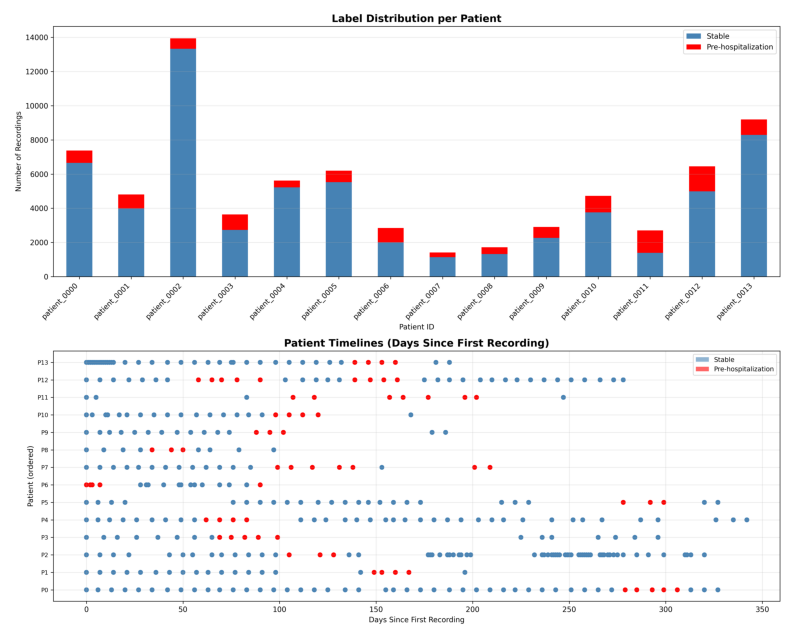

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("../explore_data_out/data_exploration.png")

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")  # hide axes
plt.show()

In [ ]:
import sys
import re
import importlib.util
from pathlib import Path

import torch

module_path = (Path.cwd() / "../src_v6_2/main_v2.py").resolve()
if not module_path.exists():
    raise FileNotFoundError(f"Could not find: {module_path}")

spec = importlib.util.spec_from_file_location("main_v2", module_path)
main_v2_mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = main_v2_mod
assert spec.loader is not None
spec.loader.exec_module(main_v2_mod)

HierarchicalTemporalTransformer = main_v2_mod.HierarchicalTemporalTransformer
LinearClassifierHead = main_v2_mod.LinearClassifierHead

# 1) Load checkpoint (best)
ckpt_dir = Path("../run_2")  # <- change if needed
base_name = "fold00_heldout_patient_0000_best"  # <- change if needed

candidates = []
p0 = ckpt_dir / base_name
if p0.exists():
    candidates.append(p0)
candidates += sorted(ckpt_dir.glob(base_name + "*.pt"))
candidates += sorted(ckpt_dir.glob(base_name + "*.pth"))


if not candidates:
    raise FileNotFoundError(f"No checkpoint found for {base_name} in {ckpt_dir}")

ckpt_path = candidates[0]
print("Loading:", ckpt_path)

ckpt = torch.load(ckpt_path, map_location="cpu")
model_state = ckpt["model_state"]
head_state = ckpt["head_state"]
cfg = ckpt.get("cfg", {}) or {}

# infer key hyperparams from checkpoint tensors
# d_model from classifier head: (2, d_model)
d_model = int(head_state["linear.weight"].shape[1])


# input_dim from first projection: (d_model, input_dim)
def infer_input_dim(sd):
    # common key in your code: seg.token_proj.0.weight
    for k in sd.keys():
        if re.fullmatch(r"seg\.token_proj\.\d+\.weight", k):
            w = sd[k]
            return int(w.shape[1])
    # fallback: search any linear that maps input_dim -> d_model
    for k, v in sd.items():
        if k.endswith("token_proj.0.weight") and v.ndim == 2:
            return int(v.shape[1])
    raise KeyError("Could not infer input_dim from model_state keys.")


input_dim = infer_input_dim(model_state)

# model type: use cfg if present, else infer from state_dict keys
model_type = str(cfg.get("model_type", "")).lower()
if model_type not in {"transformer", "gru"}:
    if any("sess_enc" in k or ".enc." in k for k in model_state.keys()):
        model_type = "transformer"
    elif any(".gru." in k for k in model_state.keys()):
        model_type = "gru"
    else:
        model_type = "transformer"  # default guess

print(f"Inferred: model_type={model_type}, input_dim={input_dim}, d_model={d_model}")

# --- instantiate model/head (requires your classes to already be defined/imported in the notebook) ---
if model_type == "transformer":
    model = HierarchicalTemporalTransformer(
        input_dim=input_dim,
        d_model=d_model,
        n_heads=int(cfg.get("n_heads", 4)),
        seg_layers=int(cfg.get("seg_n_layers", 2)),
        sess_layers=int(cfg.get("sess_n_layers", 2)),
        ff_mult=int(cfg.get("ff_mult", 4)),
        dropout=float(cfg.get("dropout", 0.0)),
        n_time_freqs=int(cfg.get("n_time_freqs", 0)),
        use_pos=bool(cfg.get("use_pos", True)),
        use_dt=bool(cfg.get("use_dt", True)),
        use_session_gaps=bool(cfg.get("use_session_gaps", True)),
        max_window=int(cfg.get("session_window", 4)),
    )
else:
    raise ValueError(f"Unknown model_type={model_type}")

head = LinearClassifierHead(d_model, 2)

# --- load weights ---
model.load_state_dict(model_state, strict=True)
head.load_state_dict(head_state, strict=True)


# 4) Count parameters (trainable vs non-trainable)
def count_params(module: torch.nn.Module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return total, trainable, non_trainable


m_tot, m_tr, m_non = count_params(model)
h_tot, h_tr, h_non = count_params(head)

print("\nParameter counts:")
print(f"  model: total={m_tot:,} | trainable={m_tr:,} | non-trainable={m_non:,}")
print(f"  head : total={h_tot:,} | trainable={h_tr:,} | non-trainable={h_non:,}")
print(
    f"  ALL  : total={m_tot+h_tot:,} | trainable={m_tr+h_tr:,} | non-trainable={m_non+h_non:,}"
)

Loading: ../run_2/fold00_heldout_patient_0000_best.pt
Inferred: model_type=transformer, input_dim=784, d_model=256

Parameter counts:
  model: total=3,369,472 | trainable=3,369,472 | non-trainable=0
  head : total=514 | trainable=514 | non-trainable=0
  ALL  : total=3,369,986 | trainable=3,369,986 | non-trainable=0


In [13]:
print(model)

HierarchicalTemporalTransformer(
  (seg): SegmentTransformer(
    (token_proj): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
    )
    (pos_enc): FourierScalarEncoding()
    (dt_enc): FourierScalarEncoding()
    (time_proj): Linear(in_features=16, out_features=256, bias=True)
    (enc): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2